In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.cm as cm
import matplotlib.colors as colors
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.lines import Line2D
import warnings; warnings.simplefilter('ignore')
import sys
import h5py
import pandas as pd
import seaborn as sns
sys.path.insert(0, '/Users/jsmonzon/Research/SatGen/mcmc/src/')
import jsm_ancillary
import jsm_visualize
import jsm_SHMR
import jsm_mcmc
from jsm_stellarhalo import Tree_Reader
import jsm_models
import evolve as ev
import galhalo as gh
import profiles as profiles
import config as cfg
import evolve as ev
import os
from matplotlib import colors
from matplotlib.cm import ScalarMappable

In [3]:
plt.style.use('../../../SatGen/notebooks/paper1/paper.mplstyle')
double_textwidth = 7.0 #inches
single_textwidth = 3.5 #inches
levelz = [1-0.99, 1-0.95, 1-0.68]

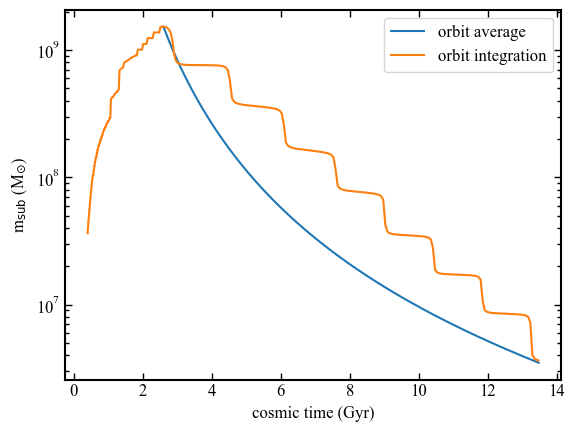

In [4]:
early = jsm_visualize.Tree_Vis(file="../../../StellarHalo/data/four_examples/DF/early_evo.npz", merger_crit=-2, fesc=0.2, scatter=False, verbose=False)

plt.plot(early.CosmicTime, early.ave_mass[44], label="orbit average")
plt.plot(early.CosmicTime, early.mass[44], label="orbit integration")
plt.ylabel("m$_{\\rm sub}$ (M$_{\\odot}$)")
plt.xlabel("cosmic time (Gyr)")
plt.yscale("log")
plt.legend()
plt.show()

In [5]:
early = jsm_visualize.Tree_Vis(file="../../../MassSpec/data/local_trees/evolved_trees/tree_13.2.npz", merger_crit=-2, fesc=0.2, scatter=False, verbose=False)

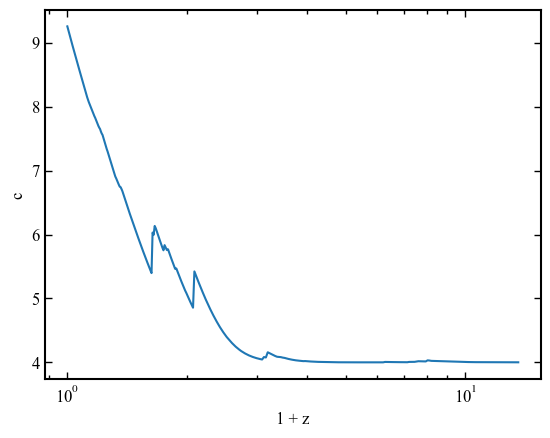

In [6]:
plt.plot(1 + cfg.zsample, early.concentration[0])
plt.xscale("log")
plt.ylabel("c")
plt.xlabel("1 + z")
plt.show()

In [7]:
wow = []
for sub_ii in range(early.Nhalo):
    if early.acc_order[sub_ii] == 1:
        host_c = early.concentration[0, early.acc_index[sub_ii]]
        sub_c  = early.acc_concentration[sub_ii]
        z_acc  = np.log10(1 + early.acc_redshift[sub_ii])
        alpha  = ev.alpha_from_c2(host_c, sub_c)
        wow.append([host_c, sub_c, z_acc, alpha])

In [8]:
test = np.array(wow)

Text(0, 0.5, 'sub c')

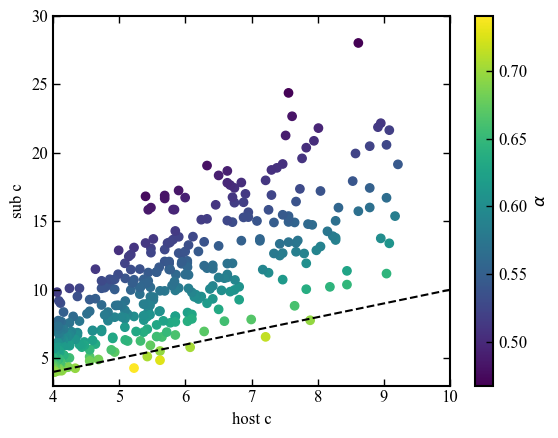

In [9]:
plt.scatter(test[:, 0], test[:, 1], c=test[:, 3])
plt.plot(np.linspace(4, 30), np.linspace(4, 30),color="k", ls="--")
plt.xlim(4, 10)
plt.ylim(3, 30)

plt.colorbar(label="$\\alpha$")
plt.xlabel("host c")
plt.ylabel("sub c")

Text(0.5, 0, 'log (1 + zacc)')

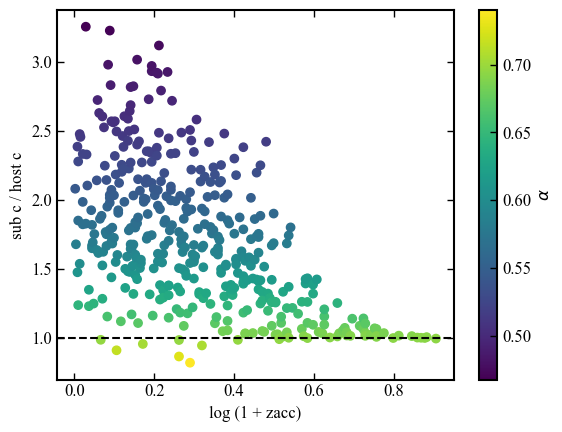

In [10]:
plt.scatter(test[:, 2], test[:, 1]/test[:, 0], c=test[:, 3])
# plt.plot(np.linspace(4, 30), np.linspace(4, 30))
# plt.xlim(4, 8)
# plt.ylim(4, 30)
plt.axhline(1, ls="--", c="k")

plt.colorbar(label="$\\alpha$")
plt.ylabel("sub c / host c")
plt.xlabel("log (1 + zacc)")

In [27]:
early = jsm_visualize.Tree_Vis(file="../../../StellarHalo/data/four_examples/DF/early_evo.npz", merger_crit=-2, fesc=0.2, scatter=False, verbose=False)

In [29]:
np.where(early.acc_order == 1)

(array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
        35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51,
        52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68,
        69, 70, 71, 72, 73, 74]),)

In [34]:
np.argsort(early.acc_mass)

array([158,  23, 153, 156, 108, 137, 134,  97, 157,  94,  92, 149, 111,
        27,  52, 172, 104, 168,  33, 167,  58, 133,  61,  85, 100, 126,
       160,  86, 102,  88,  48, 120, 159,  13,  53, 150, 142, 151,  60,
       161,  84, 109, 138, 169,  95,  26,  75, 136,  28, 164, 162,  18,
       152,  93,  44,  40,  74, 171, 128,  55,  16,  68,   9, 166, 145,
        11,  49,  82,  89,  78, 127,  77,  64,  76, 146, 144, 154,   7,
        70,  83, 130, 132, 115, 131, 163, 170,  29, 105,  34, 114, 112,
        47,   1,   3, 155,  91,  46,  67,  17, 139,  99, 135, 141, 116,
       129, 118, 148,   4,  96,  12, 113, 117, 103,  15,  35, 101,  98,
        51,  59,  56,  81, 147, 165, 121,  71,  38,  54,  24, 124, 106,
         8,  31,  90,  21,  69,   2,  66,  73,  37, 143,  80,  42,   5,
        10, 122, 125, 140, 107, 123,  87,  43,  57,  45,  72,  41, 110,
        79,   6,  25,  30,  22,  50,  20,  62, 119,  65,  19,  36,  32,
        63,  14,  39,   0])

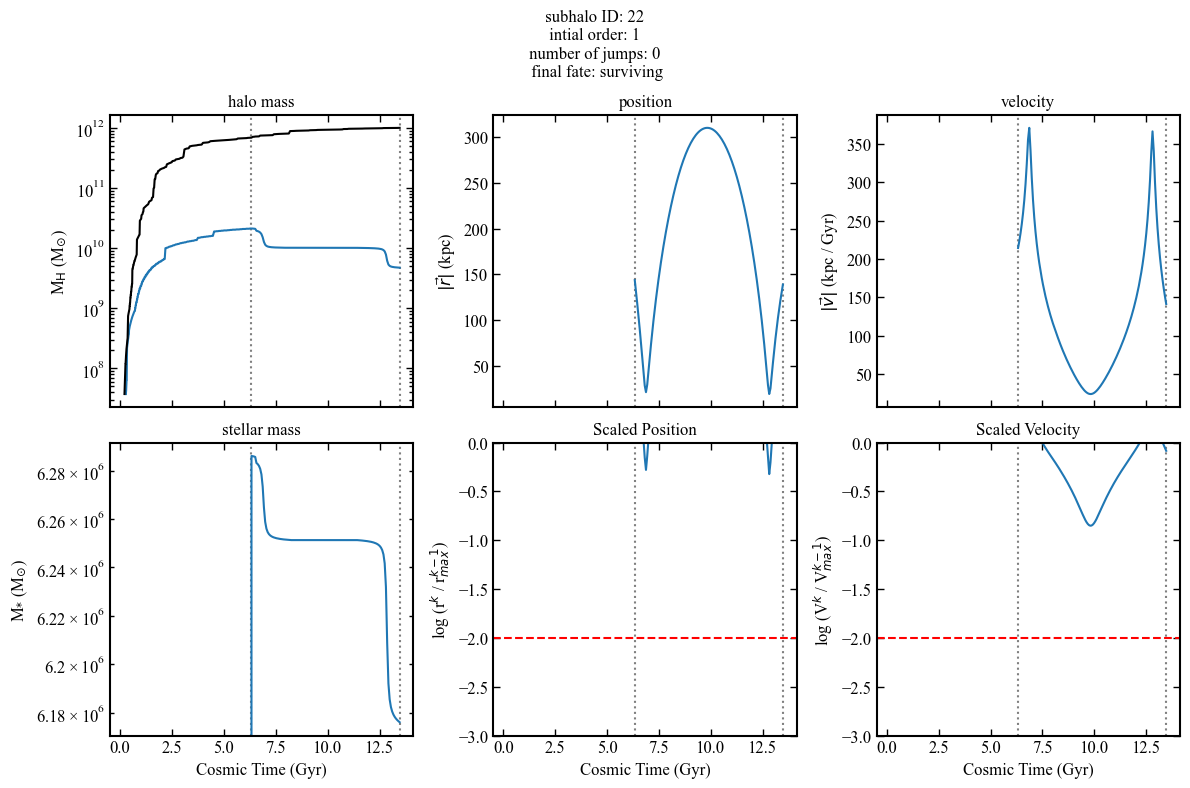

In [81]:
early.plot_subhalo_properties(subhalo_ind=22)

In [ ]:
sub_ind = 22
acc_idx = early.acc_index[sub_ind]

Mv = early.mass[sub_ind, acc_idx:]
t  = early.CosmicTime[acc_idx:]

# drop any unresolved snapshots (mass == -99)
msk = Mv > 0
Mv = Mv[msk]
t  = t[msk]

c2 = gh.c2_Zhao09(Mv, t)

plt.plot(early.CosmicTime,  early.concentration[sub_ind])
plt.axhline(early.acc_concentration[sub_ind])
plt.axhline(c2, ls="--")

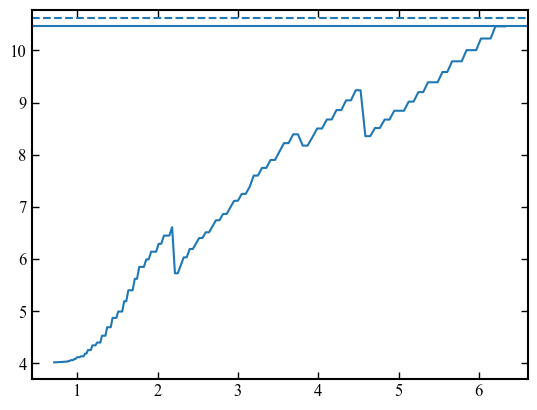

In [86]:
plt.plot(early.CosmicTime,  early.concentration[sub_ind])
plt.axhline(early.acc_concentration[sub_ind])
plt.axhline(c2, ls="--")

# plt.plot(early.CosmicTime[early.acc_index[sub_ind]: ],  early.concentration[sub_ind, early.acc_index[sub_ind]: ])


In [95]:
for sub_ind in [5, 10, 15, 20, 22, 30]:
    acc_idx = early.acc_index[sub_ind]
    Mv = early.mass[sub_ind, acc_idx+1:]
    t  = early.CosmicTime[acc_idx+1:]
    msk = Mv > 0
    c2 = gh.c2_Zhao09(Mv[msk], t[msk])
    print(f"sub={sub_ind}  c2_computed={c2:.4f}  c2_stored={early.acc_concentration[sub_ind]:.4f}  diff={c2 - early.acc_concentration[sub_ind]:.4f}")

sub=5  c2_computed=22.5825  c2_stored=19.9735  diff=2.6090
sub=10  c2_computed=13.1533  c2_stored=12.2200  diff=0.9333
sub=15  c2_computed=15.5842  c2_stored=13.8551  diff=1.7291
sub=20  c2_computed=11.1421  c2_stored=10.9142  diff=0.2278
sub=22  c2_computed=10.5076  c2_stored=10.4616  diff=0.0460
sub=30  c2_computed=5.5421  c2_stored=5.5197  diff=0.0225
